# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.optimize import minimize
from scipy import stats

data = np.genfromtxt('../../labs/03/data/claym2.csv', delimiter=',', names=True, skip_header=1)
df = pd.DataFrame(data)
data = df

print(df)

         t_days  flux_rel  sigma_flux
0      0.000000  1.008183    0.001217
1      0.020833  1.007333    0.001217
2      0.041667  1.006133    0.001217
3      0.062500  1.004460    0.001217
4      0.083333  1.005183    0.001217
...         ...       ...         ...
1258  27.312500  0.998691    0.001217
1259  27.333333  1.001820    0.001217
1260  27.354167  0.999690    0.001217
1261  27.375000  1.001103    0.001217
1262  27.395833  1.000193    0.001217

[1263 rows x 3 columns]


## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

#NETID = 'claym2'  # <-- set this
d = df #np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t.iloc[-1]:.1f} days; stated sigma = {sigma.iloc[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.22 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

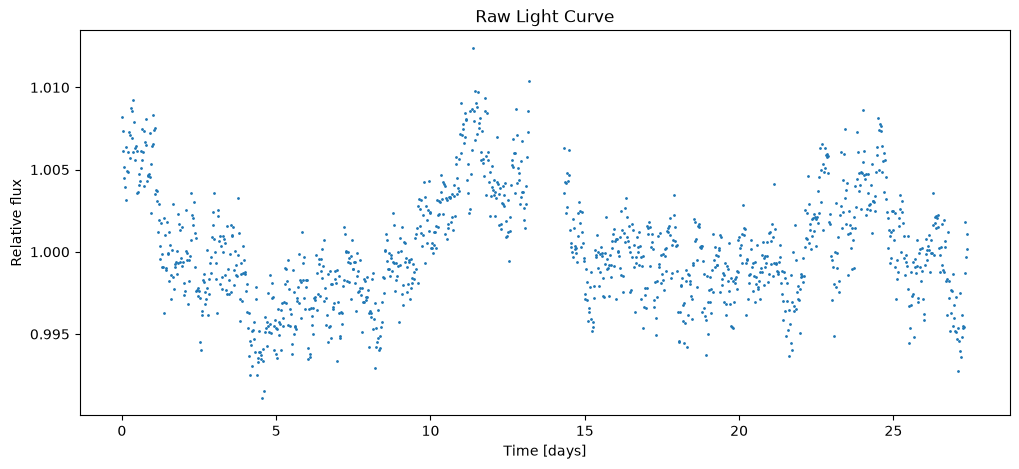

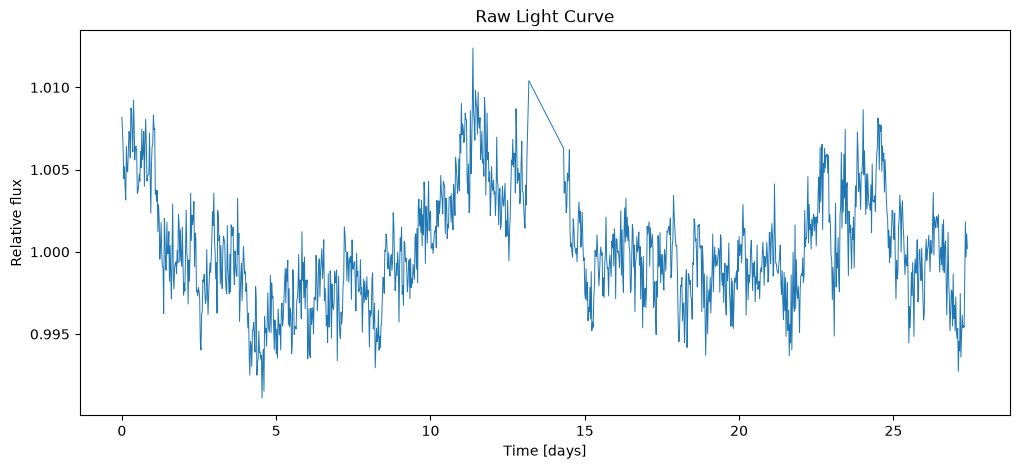

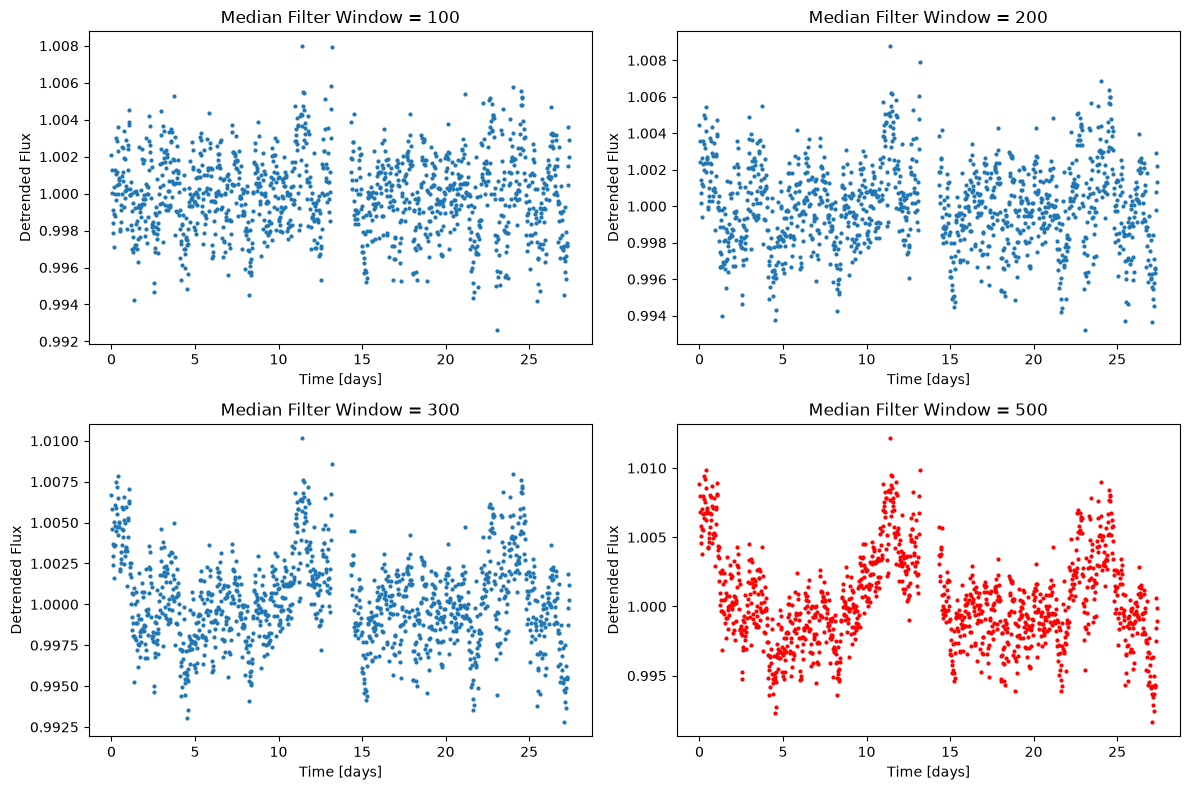

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(t, flux, '.', markersize=2)

plt.xlabel("Time [days]")
plt.ylabel("Relative flux")
plt.title("Raw Light Curve")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, flux, '-', linewidth=0.7)
plt.xlabel("Time [days]")
plt.ylabel("Relative flux")
plt.title("Raw Light Curve")

plt.show()

#---------

windows = [100, 200, 300, 500]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, window in zip(axes.ravel(), windows):
    trend = median_filter(flux, size=window)
    flux_detrended = flux / trend

    if window == 500:
        ax.plot(t, flux_detrended, '.', markersize=4, color="red")
    else:
        ax.plot(t, flux_detrended, '.', markersize=4)

    ax.set_title(f"Median Filter Window = {window}")
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Detrended Flux")
    #ax.set_ylim(0.992, 1.008) #Scale not changing now

plt.tight_layout()
plt.show()


In [4]:
trend_window = median_filter(flux, size=500)
detrended_window = flux / trend_window #change this and variable for altered data

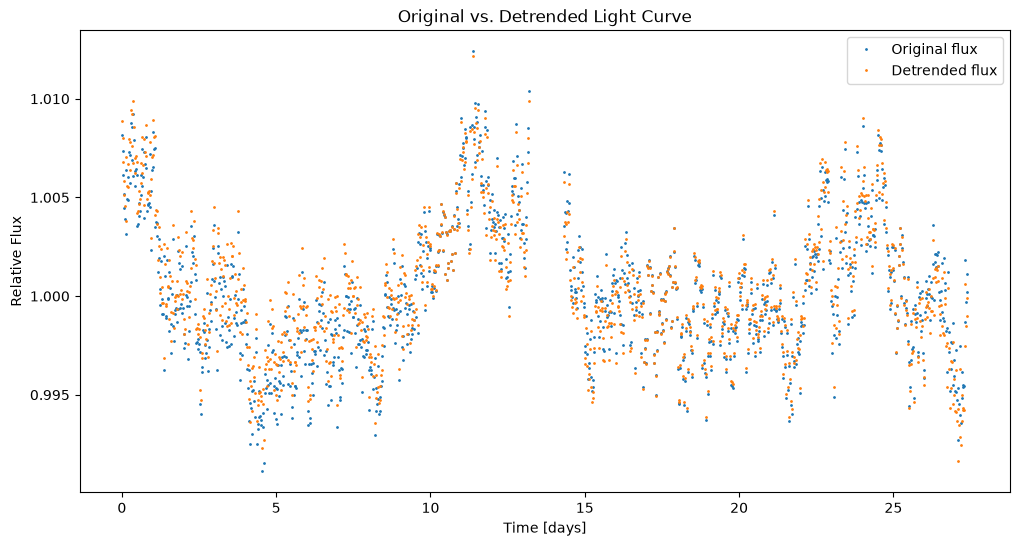

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(t,flux,'.',markersize=2,label='Original flux')
plt.plot(t,flux_detrended,'.',markersize=2,label='Detrended flux')

plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.title("Original vs. Detrended Light Curve")
plt.legend()

plt.show()

I selected the median filter method as it seemed the easiest to test a variety of windows on the data. I ended up testing four windows to directly compare the samples. In each sample, it is very difficult to single-handedly point out any light curve detection until you climb higher. I was hoping that a large/small enough window would allow the method to follow variation without removing signal. Since nothing is visible, a shrinking filter window is not optimal. 

Eventually, I settled for a 500-point smoothing window. The scale is not completely longer than the quick transits, allowing the model to follow instead of remove the signal. Additionally, we can see the model does not drastically improve above 300, making sure little error is introduced. Since the transit is pretty quick, I wanted a model that supports smoothing for that duration. 500 gets rid of daily variation while keeping dips as smooth as possible, showing the new transits when the baseline was removed.

Comparing the Detrended Flux with the Flux, they are fairly similar. There is a little more smoothing in the Detrended version.

In [6]:
guesses = [5,10,0.005,12,1]

#t0,P (t between dip),depth,duration,baseline

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
<span style="color:red">2. Estimate uncertainties **two ways**:</span>
   - <span style="color:red">from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - <span style="color:red">by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.</span>
3. <span style="color:red">The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).</span>
4. <span style="color:red">**Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.</span?

<span style="color:red">**----EVERYTHING IN RED WAS NOT STARTED----**</span>

<span style="color:red">**----EVERYTHING IN RED WAS NOT STARTED----**</span>

In [7]:
y = detrended_window
t_fit = t.to_numpy() if hasattr(t, "to_numpy") else np.asarray(t)
sigma_fit = sigma.to_numpy() if hasattr(sigma, "to_numpy") else np.asarray(sigma)

def neg_log_likelihood(parameters):
    t0, period, depth, duration, baseline = parameters

    # # Reject physically unreasonable parameters
    # if period <= 0 or duration <= 0 or duration >= period:
    #     return 1e100

    #caught it trying to do things I don't approve! ^

    model = transit_model(t_fit,t0,period,depth,duration,baseline)
    residuals = y - model
    log_likelihood = -0.5 * np.sum((residuals / sigma_fit)**2+ np.log(2 * np.pi * sigma_fit**2))

    return -log_likelihood #gives max when minimized

result = minimize(neg_log_likelihood,x0=guesses,method='Nelder-Mead') 
#making a LLF with the guesses for best fits, refitting with a new transit model

best_t0, best_period, best_depth, best_duration, best_baseline = result.x

print(f"t0       = {best_t0:.5f} days")
print(f"Period   = {best_period:.5f} days")
print(f"Depth    = {best_depth:.5f}")
print(f"Duration = {best_duration:.5f} days")
print(f"Baseline = {best_baseline:.5f}")

t0       = 5.93880 days
Period   = 11.93055 days
Depth    = 0.00621
Duration = 10.99740 days
Baseline = 1.00488


In [8]:
new_model = transit_model(t_fit,best_t0,best_period,best_depth,best_duration,best_baseline)
residuals = y - new_model

In [9]:
#ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
phase = ((t_fit - best_t0 + 0.5 * best_period)% best_period) - 0.5 * best_period

sort_idx = np.argsort(phase)
phase_sorted = phase[sort_idx]
flux_sorted = y[sort_idx]
model_sorted = new_model[sort_idx]
residuals_sorted = residuals[sort_idx]

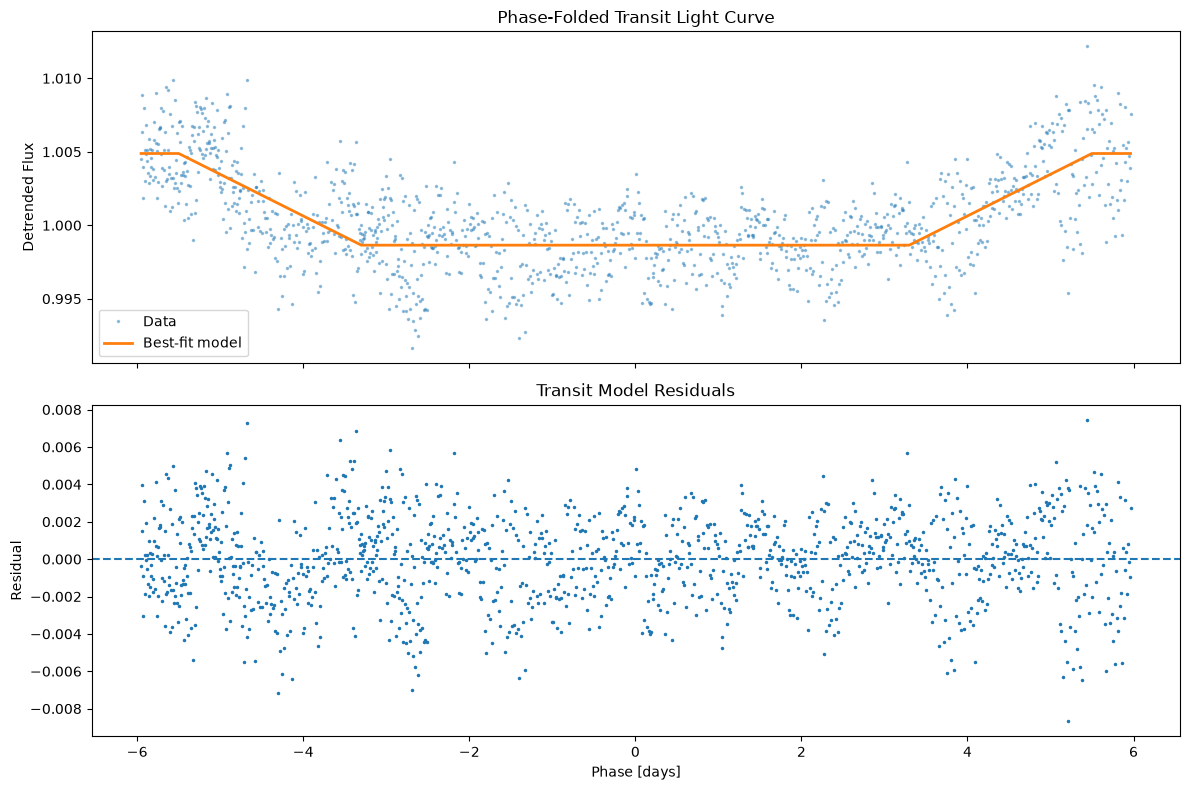

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(phase_sorted,flux_sorted,'.',markersize=3,label='Data',alpha=0.4)
axes[0].plot(phase_sorted,model_sorted,linewidth=2,label='Best-fit model')
axes[0].set_ylabel("Detrended Flux")
axes[0].set_title("Phase-Folded Transit Light Curve")
axes[0].legend()
#--------------
axes[1].plot(phase_sorted,residuals_sorted,'.',markersize=3)
axes[1].axhline(0, linestyle='--')
axes[1].set_xlabel("Phase [days]")
axes[1].set_ylabel("Residual")
axes[1].set_title("Transit Model Residuals")

plt.tight_layout()
plt.show()

The best fit model actaully look pretty good here, following the data from the new transit model. Additionally, the residuals are nicely spread out and do not particularly seem to be following a pattern. It is a little oscillate-y at the edges, but not crazy. Below, you can see that indeed, the edges are slighly off of the QQ-plot. The inside looks fairly accurate.

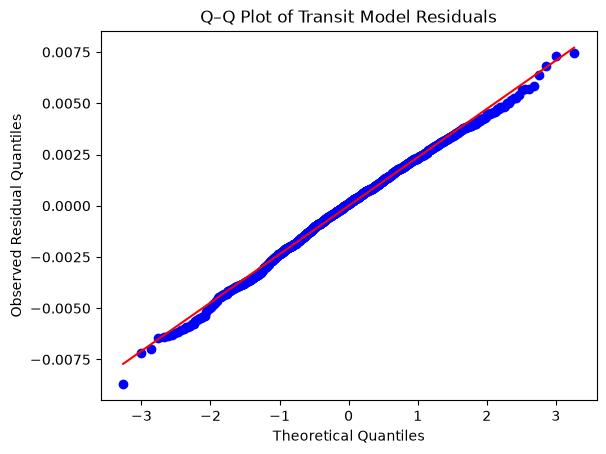

In [11]:
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q–Q Plot of Transit Model Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Residual Quantiles")

plt.show()

**FINAL ANSWER:** $\delta = $ ___ $\pm$ ___ ppt, $P = $ ___ $\pm$ ___ d, $t_0 = $ ___ $\pm$ ___ d

**Which uncertainty and why (a short paragraph):**

*your answer goes here*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* The first thing I noticed is that if my version here is correct, the window which the AI notebook uses is wrong. The detrend has kept the values of the window so low that the variation has dissapeared yet has gotten a curve result for the Phase-Fold. Somewhere, the values must have been adjusted or altered to get this result, as my plots cannot replicate a result similar with a bad window.

<span style="color:red">*Flaw 2:*</span>

<span style="color:red">*Flaw 3:*</span>

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

For AI-Use, I am trying to alter how I use it each lab. I think I used it in ways that I do not like using it for during lab 1/2. This time, I am actively trying new methods. I used AI to help me get my plots in good presentation order for number one, as well as to help me arrange and de-bug the four Median Filter plots. I wanted to showcase four test plots and was failing to execute them correctly. For part two, I used it to help me get a working LL function off the ground and to coordinate the phase. I am slowly learning how to create beautiful looking plots, so it helps me arrange and present the visualizations as well.

**VERIFICATION PLAN:**

For the parts specified above, I could just visually check, for the most part, what it wrote. When it came to the functions, I couldn't verify every line but I compared closely with lecture notes but the functions are essentailly just the converted math given to us. For the graph end result, I wanted to check it with a QQ-plot to confirm what I was seeing visually in the residual plot. I felt that that was a very strong indicator that I was seeing what should be given. I commented out some code that my LLM wrote for the secion where it decided to change some values that might be "unreasonable".

I am still believing that 500 is the correct window, as it was about the smallest window that I put in the data that yeilded some results in the Phase-Folded Transit Light Curve (PFTLC) and Residuals Light Curve (RLC). Every other window made those lines nearly flat with random spreads of data. However, it feels weird to be picking a window that creates an identical trend of original data in the detrended data... it's in the name: detrend... No other window seems to give any real indication of anything in the PFTLC and RLC, and it blows up the Q-Q Plots. 500 gives you something in those plots and doesn't explode the Q-Q Plot.

I have also had my LLM generate some tests below as I am really stuck on whether or not my results are abolutely garbage or something useful. After all of the tests below, I am more confident that I have done something correctly. The AI-solution that is wrong seems to do the opposite of what I have done. Maybe that is a good thing.

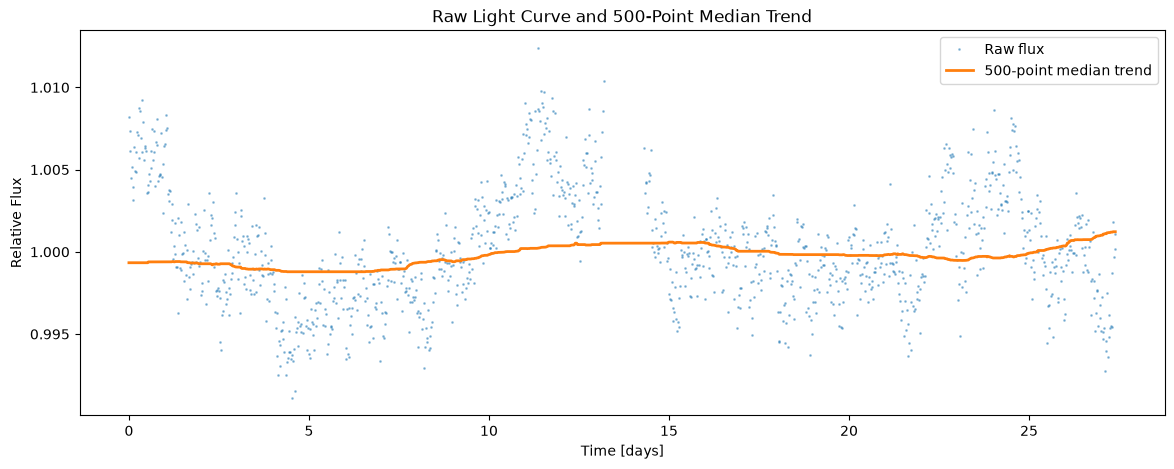

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(t, flux, '.', markersize=2, alpha=0.4, label='Raw flux')
plt.plot(t, trend_window, linewidth=2, label='500-point median trend')

plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.title("Raw Light Curve and 500-Point Median Trend")
plt.legend()
plt.show()

I mean, it looks smooth to me. This looks like it could be a correct indication. It is slow and follows the variation without aggressively jumping.

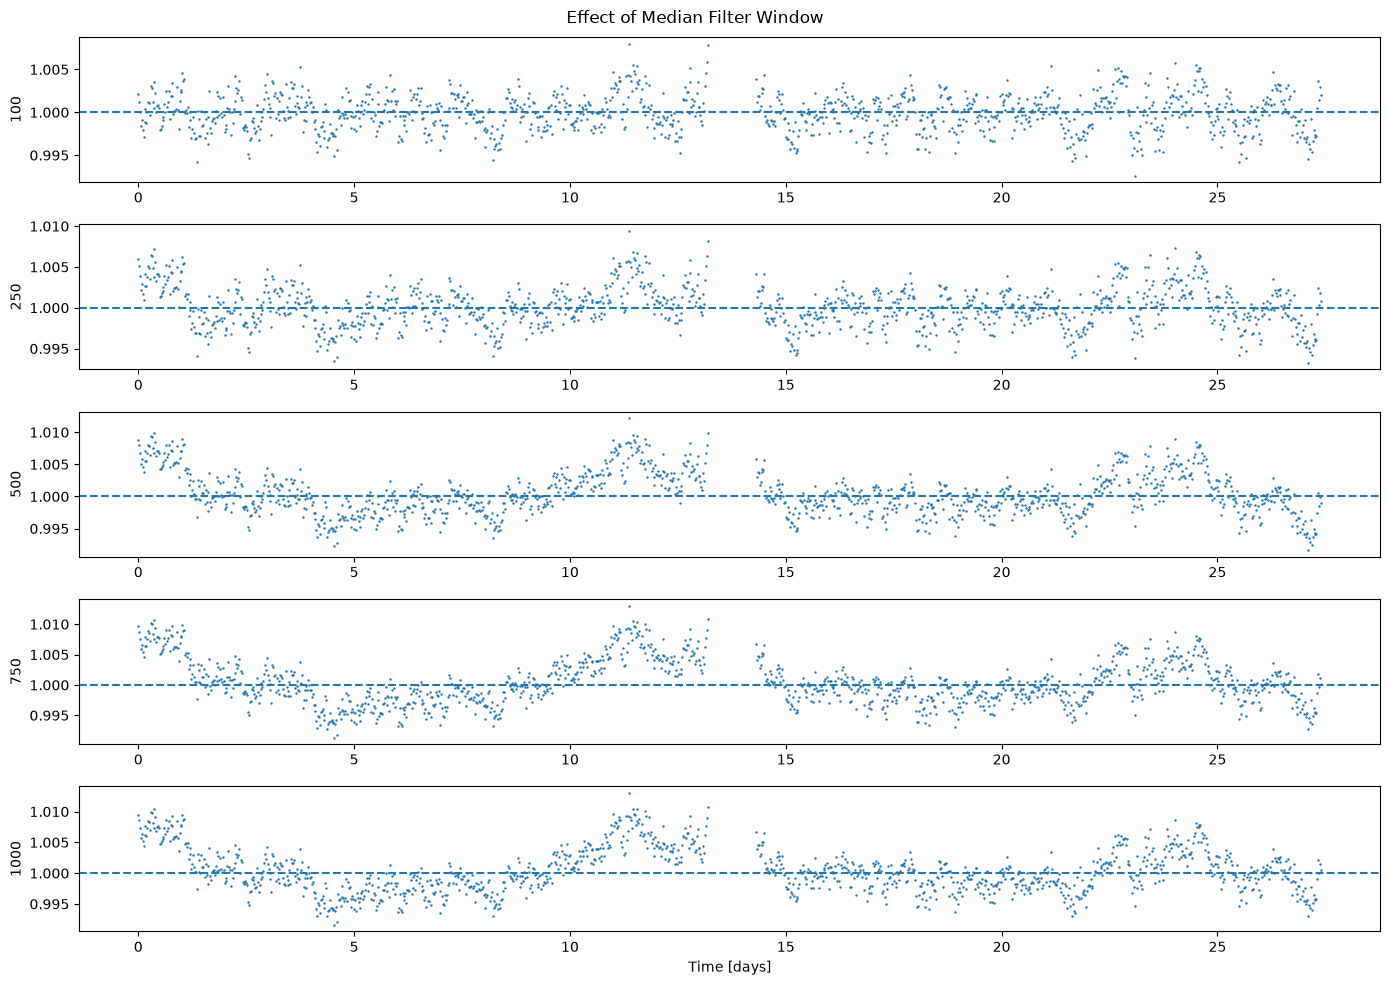

In [13]:
windows = [100, 250, 500, 750, 1000]

plt.figure(figsize=(14, 10))

for i, window in enumerate(windows):

    trend = median_filter(flux, size=window)
    detrended = flux / trend

    plt.subplot(len(windows), 1, i + 1)
    plt.plot(t, detrended, '.', markersize=1.5)

    plt.axhline(1.0, linestyle='--')

    plt.ylabel(f'{window}')

plt.xlabel("Time [days]")
plt.suptitle("Effect of Median Filter Window")
plt.tight_layout()
plt.show()

Here, we see how the windows keep the same transit areas as the graph throughout. It doesn't LOOK like any of these ends up being a terrible guess. 